## K-Nearest Neighbors (Classification)

In [1]:
import pandas as pd
df = pd.read_csv('diabetes_unclean.csv')
df.head()
df.drop(['ID','No_Pation'],axis=1,inplace=True)

In [2]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  1009 non-null   object 
 1   AGE     1008 non-null   float64
 2   Urea    1008 non-null   float64
 3   Cr      1007 non-null   float64
 4   HbA1c   1006 non-null   float64
 5   Chol    1007 non-null   float64
 6   TG      1007 non-null   float64
 7   HDL     1008 non-null   float64
 8   LDL     1007 non-null   float64
 9   VLDL    1008 non-null   float64
 10  BMI     1009 non-null   float64
 11  CLASS   1009 non-null   object 
dtypes: float64(10), object(2)
memory usage: 94.7+ KB


In [3]:
df.fillna(df.mean(numeric_only=True),inplace=True)

In [4]:
x = df.drop('CLASS',axis=1)
y = df['CLASS']

In [5]:
x = pd.get_dummies(x,drop_first=True)

In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=20)

In [7]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(x_train,y_train)
y_pred = knn.predict(x_test)

In [8]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

0.8712871287128713


In [9]:
df = pd.read_csv('cancer.csv')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [11]:
df.drop(['id','Unnamed: 32'],axis=1,inplace=True)

In [12]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [13]:
x = df.drop('diagnosis',axis=1)
y = df['diagnosis']

In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=20)

In [15]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(x_train,y_train)
y_pred = knn.predict(x_test)

In [16]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

0.9473684210526315


In [17]:
acc=[]
for i in range(3,24):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train,y_train)
    y_pred = knn.predict(x_test)
    acc.append(accuracy_score(y_test,y_pred))
print(max(acc))
print(acc.index(max(acc))+3)

0.9473684210526315
7


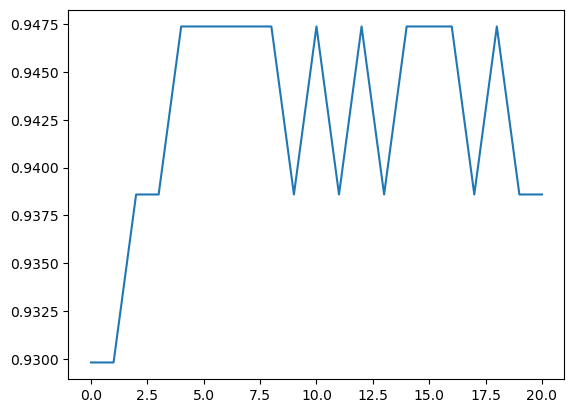

In [18]:
import matplotlib.pyplot as plt
plt.plot(acc)
plt.show()

In [19]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(x_train,y_train)
y_pred = knn.predict(x_test)
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

0.9473684210526315


In [20]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[65  1]
 [ 5 43]]


In [21]:
y_act = ['Y','Y','Y','N','N','N','Y','Y','N','N','Y','Y','Y','N','N']
y_pred = ['Y','Y','N','N','N','N','Y','Y','Y','Y','Y','N','Y','Y','N']
cm = confusion_matrix(y_act,y_pred)

In [22]:
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

In [23]:
#Accuracy
print((TN+TP)/(TN+TP+FN+FP))

0.6666666666666666


In [24]:
#Precision
print(TP/(TP+FP))

0.6666666666666666


In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_act,y_pred))

              precision    recall  f1-score   support

           N       0.67      0.57      0.62         7
           Y       0.67      0.75      0.71         8

    accuracy                           0.67        15
   macro avg       0.67      0.66      0.66        15
weighted avg       0.67      0.67      0.66        15



In [26]:
from sklearn.datasets import load_iris

iris = load_iris()
x = iris.data
y = iris.target

In [27]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,
                                                random_state=42)

In [28]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)
y_pred = knn.predict(x_test)
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [29]:
df = pd.read_csv('Churn.csv')
df.head()

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Decision Tree (Classification)

In [30]:
import pandas as pd
df = pd.read_csv('decision.csv')

In [31]:
x = df.drop('Job Offered',axis=1)
y = df['Job Offered']

In [32]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='entropy',random_state=10)
dt.fit(x,y)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,10
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


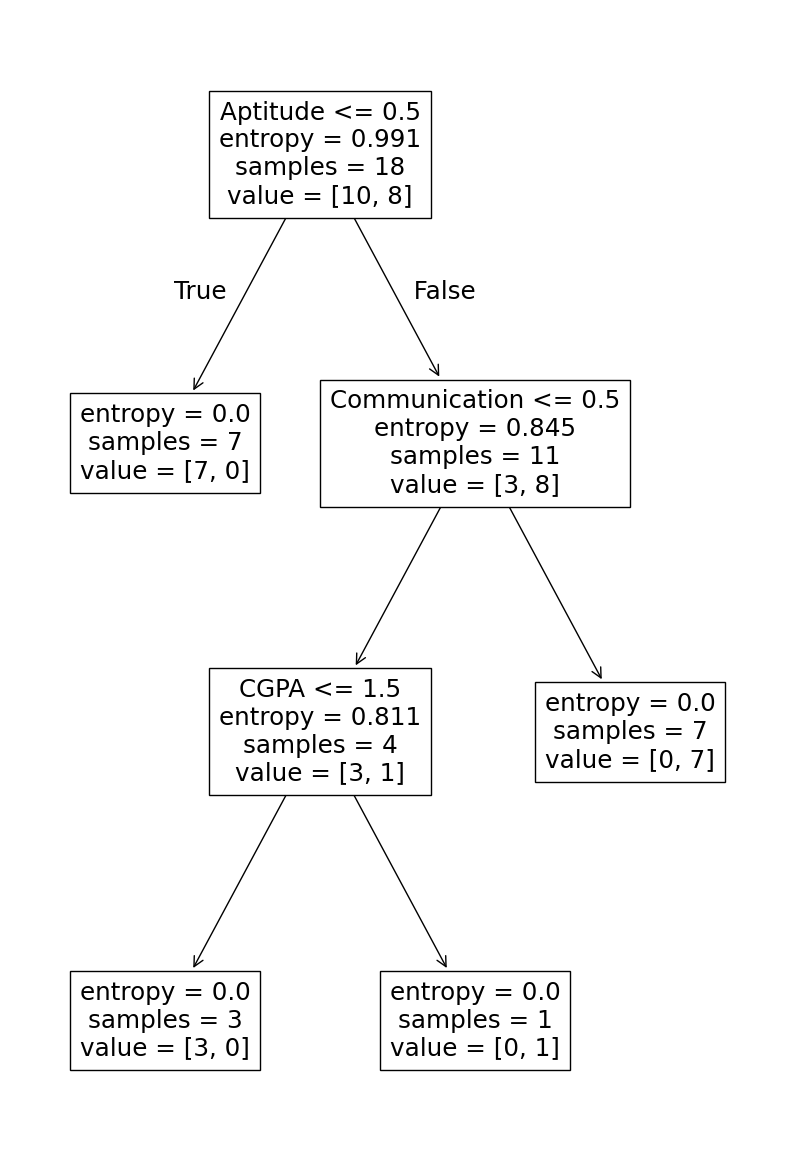

In [33]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(10,15))
plot_tree(dt,feature_names=x.columns)
plt.show()

In [34]:
df = pd.read_csv('Churn.csv')
df.head()

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
df.drop(['Unnamed: 0','customerID'],axis=1,inplace=True)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [37]:
df.fillna(df.mean(numeric_only=True),inplace=True)

In [38]:
x = df.drop('Churn',axis=1)
y = df['Churn']

In [39]:
x = pd.get_dummies(x,drop_first=True)

In [40]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=10)
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
x_train = scale.fit_transform(x_train)
x_test = scale.transform(x_test)

In [41]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=21)
knn.fit(x_train,y_train)
y_pred = knn.predict(x_test)
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test, y_pred))

[[905 161]
 [159 184]]
              precision    recall  f1-score   support

          No       0.85      0.85      0.85      1066
         Yes       0.53      0.54      0.53       343

    accuracy                           0.77      1409
   macro avg       0.69      0.69      0.69      1409
weighted avg       0.77      0.77      0.77      1409



In [42]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='entropy',random_state=42)
dt.fit(x_train,y_train)
y_pred = dt.predict(x_test)
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test, y_pred))

[[879 187]
 [172 171]]
              precision    recall  f1-score   support

          No       0.84      0.82      0.83      1066
         Yes       0.48      0.50      0.49       343

    accuracy                           0.75      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.75      0.75      0.75      1409



In [43]:
from sklearn.metrics import recall_score, precision_score, f1_score
print(recall_score(y_test,y_pred,pos_label='Yes'))
print(precision_score(y_test,y_pred,pos_label='Yes'))
print(f1_score(y_test,y_pred,pos_label='Yes'))

0.49854227405247814
0.4776536312849162
0.48787446504992865


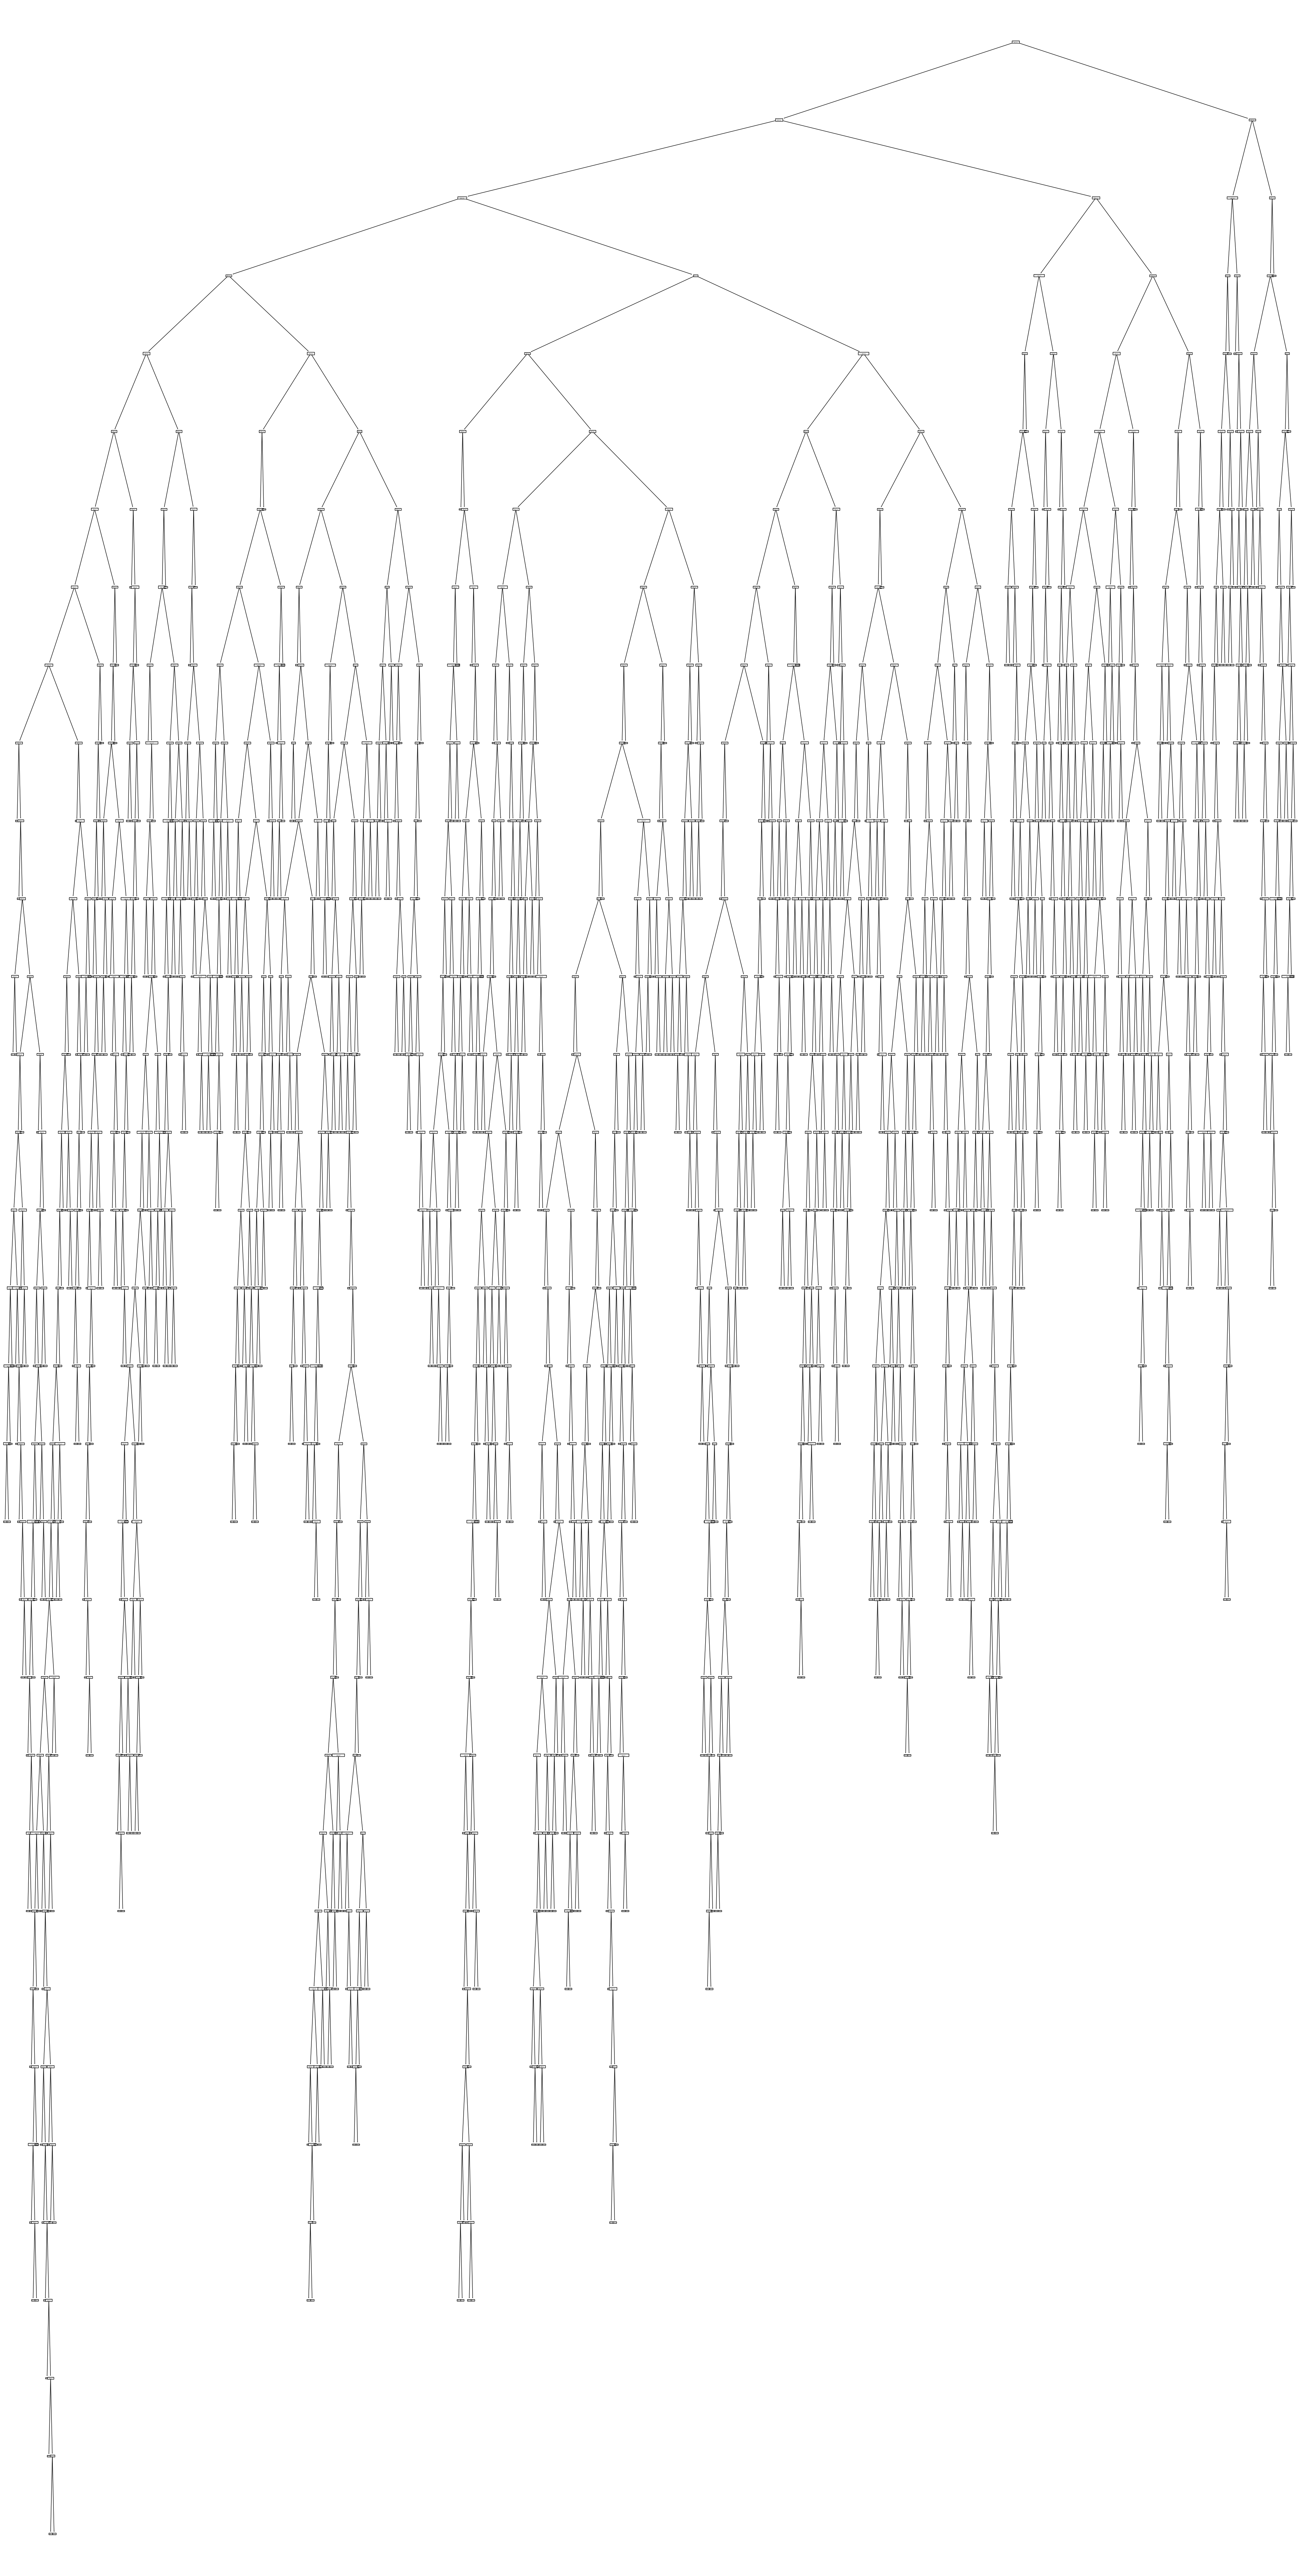

In [44]:
plt.figure(figsize=(50,100))
plot_tree(dt,feature_names=x.columns)
plt.show()

In [45]:
df = pd.read_csv('loan_approval.csv')
df.head()

,Age,Income,CreditScore,LoanAmount,Dependents,Education,SelfEmployed,PropertyArea,PreviousLoans,LoanApproved
0,25,35000.0,620,120000.0,0,Graduate,No,Urban,1,No
1,42,72000.0,780,200000.0,2,Graduate,No,Semiurban,0,Yes
2,35,58000.0,690,150000.0,1,Graduate,Yes,Rural,2,Yes
3,28,26000.0,590,100000.0,0,Not Graduate,No,Urban,1,No
4,50,85000.0,810,250000.0,3,Graduate,No,Semiurban,0,Yes


In [46]:
Age - 18
Income - 25000
CreditScore - 720
LoanAmount - 100000
Dependents - 0
Education - Not Graduate
SelfEmployed - No
PropertyArea - Urban
PreviousLoans - 0


SyntaxError: invalid syntax (4060091039.py, line 6)

In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.fillna(df.median(numeric_only=True),inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

In [ ]:
x = df.drop('LoanApproved',axis=1)
y = df['LoanApproved']
x = pd.get_dummies(x,drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train,y_train)
y_pred = knn.predict(x_test)
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test, y_pred))

In [ ]:
r_knn = recall_score(y_test,y_pred,pos_label='Yes')
p_knn = precision_score(y_test,y_pred,pos_label='Yes')
f1_knn = f1_score(y_test,y_pred,pos_label='Yes')
from sklearn.metrics import accuracy_score
acc_knn = accuracy_score(y_test, y_pred)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='entropy')
dt.fit(x_train,y_train)
y_pred = dt.predict(x_test)
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test, y_pred))

In [ ]:
r_dt = recall_score(y_test,y_pred,pos_label='Yes')
p_dt = precision_score(y_test,y_pred,pos_label='Yes')
f1_dt = f1_score(y_test,y_pred,pos_label='Yes')
acc_dt = accuracy_score(y_test, y_pred)

In [ ]:
df1 = pd.DataFrame({'Model':['KNN','Decision Tree'],
                  'Accuracy':[acc_knn,acc_dt],
                  'Precision':[p_knn,p_dt],
                  'Recall':[r_knn,r_dt],
                  'F1-Score':[f1_knn,f1_dt]})
df1

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df['Income'],df['CreditScore'])
plt.show()

In [ ]:
import seaborn as sns
sns.boxplot(data=df['LoanAmount'])

In [ ]:
import plotly.express as px
px.bar(df,
      x='Income',
      y='PropertyArea')

In [ ]:
new = df.groupby('PropertyArea',as_index=False)['Income'].mean()

In [ ]:
px.bar(new,
      x='Income',
      y='PropertyArea')

In [ ]:
plt.pie(df['LoanApproved'].value_counts(),labels=['Yes','No'])
plt.show()

In [ ]:
x_test.columns

In [ ]:
import numpy as np
x = np.array([[18,40000,720,100000,0,0,True,False,False,True]])
print(dt.predict(x))
print(knn.predict(x))

## Random Forest Classifier

In [ ]:
df = pd.read_csv('Churn.csv')
df.head()

In [ ]:
df.drop(['Unnamed: 0','customerID'],axis=1,inplace=True)

In [ ]:
df.dropna(inplace=True)

In [ ]:
x = df.drop('Churn',axis=1)
y = df['Churn']

In [ ]:
x = pd.get_dummies(x,drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=10)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=10,n_estimators=50,criterion='entropy',
                           max_depth=12)
rf.fit(x_train,y_train)

In [ ]:
y_pred = rf.predict(x_test)
print(classification_report(y_test,y_pred))

## Support Vector Classifier (SVC)

In [ ]:
x.info()

In [ ]:
from sklearn.svm import SVC
s = SVC(kernel='rbf',C=10,random_state=10)
s.fit(x_train,y_train)
y_pred = s.predict(x_test)
print(classification_report(y_test,y_pred))

## CNN (Convulation Neural Network)
- Convulation Layer
- Pooling Layer
- Dropout Layer
- Flatten Layer

## 9 Marks Practice Question
- Use 'loan_approval_dataset.csv' to create a dataset.
- Remove 'loan_id' from dataset
- check for null and duplicates in dataset, drop them if present.
- Remove Outliers from 'bank_asset_value' column.
- Create new column named 'total_asset_value' as a sum of residential_assets_value, commercial_assets_value, luxury_assets_value	bank_asset_value
- Remove residential_assets_value, commercial_assets_value, luxury_assets_value	bank_asset_value columns.
- Remove rows from dataset if 'loan_status' column have *Not Known* in it.
- target column - 'loan_status'
- features - All columns except 'loan_status'
- Create kNN(neighbors=21),Decision Tree(criterion=entropy, random_state=42),SVM(C=20),RandomForest(criterion=entropy, random_state=42) for testing size(0.1,0.2,0.3,0.4)
- Create a line plot comparing accuracy of all models for each testing size.

In [1]:
import pandas as pd
df = pd.read_csv('loan_approval_dataset.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,NotGraduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,NotGraduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [2]:
df.drop('loan_id',axis=1,inplace=True)

In [4]:
print(df.isna().any().sum())

0


In [5]:
print(df.duplicated().sum())

0


<Axes: ylabel='bank_asset_value'>

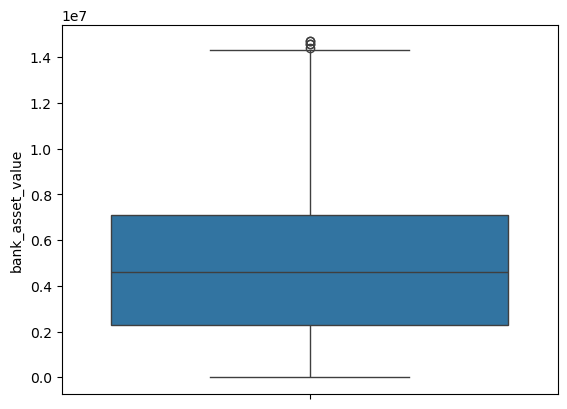

In [6]:
import seaborn as sns
sns.boxplot(df['bank_asset_value'])

In [7]:
Q1 = df['bank_asset_value'].quantile(0.25)
Q3 = df['bank_asset_value'].quantile(0.75)
IQR = Q3-Q1
ul = Q3+1.5*IQR
ll = Q1-1.5*IQR
df = df.loc[(df['bank_asset_value']>=ll) & (df['bank_asset_value']<=ul)]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4264 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   no_of_dependents          4264 non-null   int64 
 1   education                 4264 non-null   object
 2   self_employed             4264 non-null   object
 3   income_annum              4264 non-null   int64 
 4   loan_amount               4264 non-null   int64 
 5   loan_term                 4264 non-null   int64 
 6   cibil_score               4264 non-null   int64 
 7   residential_assets_value  4264 non-null   int64 
 8   commercial_assets_value   4264 non-null   int64 
 9   luxury_assets_value       4264 non-null   int64 
 10  bank_asset_value          4264 non-null   int64 
 11  loan_status               4264 non-null   object
dtypes: int64(9), object(3)
memory usage: 433.1+ KB


<Axes: ylabel='bank_asset_value'>

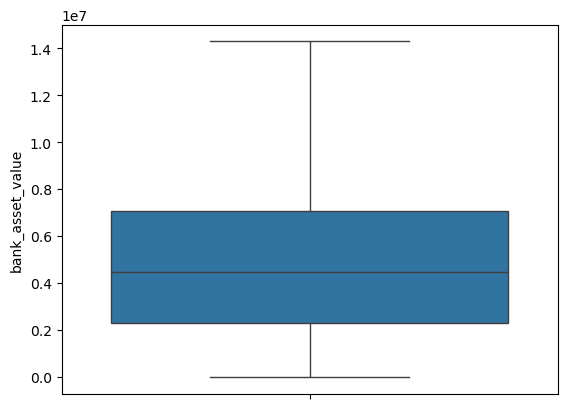

In [8]:
sns.boxplot(df['bank_asset_value'])

In [9]:
df['total_asset_value'] = df['residential_assets_value'] + df['commercial_assets_value'] 
                        + df['luxury_assets_value'] + df['bank_asset_value']

C:\Users\LJENG\AppData\Local\Temp\ipykernel_12004\563742484.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['total_asset_value'] = df['residential_assets_value'] + df['commercial_assets_value'] + df['luxury_assets_value'] + df['bank_asset_value']


In [11]:
df.drop(['residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
        ,axis=1,inplace=True)

C:\Users\LJENG\AppData\Local\Temp\ipykernel_12004\224782805.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(['residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


In [13]:
df = df.loc[df['loan_status']!='Not Known']

In [14]:
df['loan_status'].unique()

array(['Approved', 'Rejected'], dtype=object)

In [15]:
df.shape

(4261, 9)

In [17]:
x = df.drop('loan_status',axis=1)
y = df['loan_status']
x = pd.get_dummies(x,drop_first=True)

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [20]:
acc_knn=[]; acc_dt=[]; acc_rf=[]; acc_svc=[]
test = [0.1,0.2,0.3,0.4]
for i in test:
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=i,random_state=42)
    knn = KNeighborsClassifier(n_neighbors=21)
    knn.fit(x_train,y_train)
    y_pred = knn.predict(x_test)
    acc_knn.append(accuracy_score(y_test,y_pred))
    dt = DecisionTreeClassifier(criterion='entropy',random_state=42)
    dt.fit(x_train,y_train)
    y_pred = dt.predict(x_test)
    acc_dt.append(accuracy_score(y_test,y_pred))
    rf = RandomForestClassifier(criterion='entropy',random_state=42)
    rf.fit(x_train,y_train)
    y_pred = rf.predict(x_test)
    acc_rf.append(accuracy_score(y_test,y_pred))
    s = SVC(C=20)
    s.fit(x_train,y_train)
    y_pred = s.predict(x_test)
    acc_svc.append(accuracy_score(y_test,y_pred))

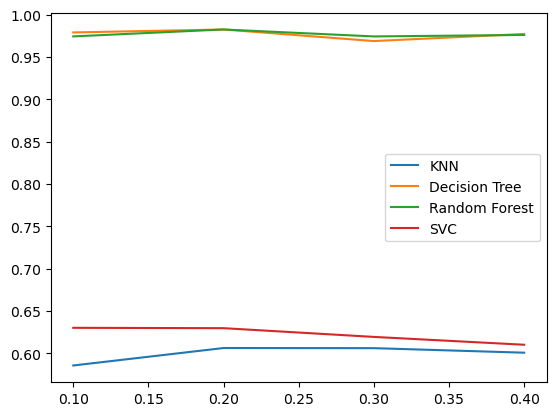

In [22]:
import matplotlib.pyplot as plt
plt.plot(test,acc_knn,label='KNN')
plt.plot(test,acc_dt,label='Decision Tree')
plt.plot(test,acc_rf,label='Random Forest')
plt.plot(test,acc_svc,label='SVC')
plt.legend()
plt.show()

In [23]:
import pandas as pd
acc = pd.DataFrame({'Test Size':[0.1,0.2,0.3,0.4],
                   'KNN':acc_knn,
                   'Decision Tree':acc_dt,
                   'Random Forest':acc_rf,
                   'SVC':acc_svc})
acc

,Test Size,KNN,Decision Tree,Random Forest,SVC
0,0.1,0.585480,0.978923,0.974239,0.629977
1,0.2,0.606096,0.982415,0.982415,0.629543
2,0.3,0.605942,0.968726,0.974199,0.619234
3,0.4,0.600587,0.977126,0.975953,0.609971


In [ ]:
df['Total_Pass'] = np.where(df['math_pass']==0,0,
                           np.where(df['reading_pass']==0,0,
                                   np.where(df['writing_pass']==0,0,1)))


In [24]:
df = pd.read_csv('candy-data.csv')
df.head()

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,100 Grand,1,0,1,0,0,1,0,1,0,0.732,0.860,66.971725
1,3 Musketeers,1,0,0,0,1,0,0,1,0,0.604,0.511,67.602936
2,One dime,0,0,0,0,0,0,0,0,0,0.011,0.116,32.261086
3,One quarter,0,0,0,0,0,0,0,0,0,0.011,0.511,46.116505
4,Air Heads,0,1,0,0,0,0,0,0,0,0.906,0.511,52.341465


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   competitorname    85 non-null     object 
 1   chocolate         85 non-null     int64  
 2   fruity            85 non-null     int64  
 3   caramel           85 non-null     int64  
 4   peanutyalmondy    85 non-null     int64  
 5   nougat            85 non-null     int64  
 6   crispedricewafer  85 non-null     int64  
 7   hard              85 non-null     int64  
 8   bar               85 non-null     int64  
 9   pluribus          85 non-null     int64  
 10  sugarpercent      85 non-null     float64
 11  pricepercent      85 non-null     float64
 12  winpercent        85 non-null     float64
dtypes: float64(3), int64(9), object(1)
memory usage: 8.8+ KB


In [26]:
df.corr(numeric_only=True)

,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
chocolate,1.000000,-0.741721,0.249875,0.377824,0.254892,0.341210,-0.344177,0.597421,-0.339675,0.104169,0.504675,0.636517
fruity,-0.741721,1.000000,-0.335485,-0.399280,-0.269367,-0.269367,0.390678,-0.515066,0.299725,-0.034393,-0.430969,-0.380938
caramel,0.249875,-0.335485,1.000000,0.059356,0.328493,0.213113,-0.122355,0.333960,-0.269585,0.221933,0.254327,0.213416
peanutyalmondy,0.377824,-0.399280,0.059356,1.000000,0.213113,-0.017646,-0.205557,0.260420,-0.206109,0.087889,0.309153,0.406192
nougat,0.254892,-0.269367,0.328493,0.213113,1.000000,-0.089744,-0.138675,0.522976,-0.310339,0.123081,0.153196,0.199375
crispedricewafer,0.341210,-0.269367,0.213113,-0.017646,-0.089744,1.000000,-0.138675,0.423751,-0.224693,0.069950,0.328265,0.324680
hard,-0.344177,0.390678,-0.122355,-0.205557,-0.138675,-0.138675,1.000000,-0.265165,0.014532,0.091810,-0.244365,-0.310382
bar,0.597421,-0.515066,0.333960,0.260420,0.522976,0.423751,-0.265165,1.000000,-0.593409,0.099985,0.518407,0.429929
pluribus,-0.339675,0.299725,-0.269585,-0.206109,-0.310339,-0.224693,0.014532,-0.593409,1.000000,0.045523,-0.220794,-0.247448
sugarpercent,0.104169,-0.034393,0.221933,0.087889,0.123081,0.069950,0.091810,0.099985,0.045523,1.000000,0.329706,0.229151


In [27]:
x = df[['chocolate']]
y = df['winpercent']

In [29]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
from sklearn.linear_model import LinearRegression
slr = LinearRegression()
slr.fit(x_train,y_train)
y_pred = slr.predict(x_test)
from sklearn.metrics import mean_absolute_error, r2_score
print(slr.coef_,slr.intercept_)
print(mean_absolute_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

[19.95503814] 41.225567897435894
11.123073606334842
0.17250262737120836


In [30]:
df.head()

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,100 Grand,1,0,1,0,0,1,0,1,0,0.732,0.860,66.971725
1,3 Musketeers,1,0,0,0,1,0,0,1,0,0.604,0.511,67.602936
2,One dime,0,0,0,0,0,0,0,0,0,0.011,0.116,32.261086
3,One quarter,0,0,0,0,0,0,0,0,0,0.011,0.511,46.116505
4,Air Heads,0,1,0,0,0,0,0,0,0,0.906,0.511,52.341465


In [31]:
x = df.drop(['competitorname','winpercent'],axis=1)
y = df['winpercent']
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
from sklearn.linear_model import LinearRegression
slr = LinearRegression()
slr.fit(x_train,y_train)
y_pred = slr.predict(x_test)
from sklearn.metrics import mean_absolute_error, r2_score
print(slr.coef_,slr.intercept_)
print(mean_absolute_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

[18.86638998  8.31168249 -0.0404909   8.73805688  4.49475553  8.75868751
 -5.05673334  0.08776222 -3.94022075  9.94857885 -4.24289722] 35.70229227432461
9.90669730061768
0.1969988833466978


In [32]:
x = df.drop(['competitorname','winpercent'],axis=1)
y = df['winpercent']
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
x_train = poly.fit_transform(x_train)
x_test = poly.transform(x_test)
from sklearn.linear_model import LinearRegression
slr = LinearRegression()
slr.fit(x_train,y_train)
y_pred = slr.predict(x_test)
from sklearn.metrics import mean_absolute_error, r2_score
print(slr.coef_,slr.intercept_)
print(mean_absolute_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

[ 8.37213632e-12  2.54310812e+01  1.01620135e+01  4.18078324e+01
 -3.40918563e+01  4.53509988e+01  2.98563613e+01  4.52662072e-01
 -4.69774025e+00  5.57886343e+00 -5.78015077e+01  3.64513340e+01
  2.54310812e+01  2.47729961e+01  1.13687833e+02  5.52417683e+01
  2.11715594e+01  2.98563613e+01  2.47729961e+01 -2.88771797e+01
 -1.08176378e+01 -1.52637165e+02  1.26832424e+00  1.01620135e+01
  9.02383693e+00  9.55679980e-13 -2.87769808e-13 -1.42108547e-14
 -1.03532423e+01  3.41060513e-13 -1.00991022e+01  1.75595095e+01
 -2.84845853e+01  4.18078324e+01 -2.53533306e+01 -2.05971256e+01
 -1.40781419e+01 -2.93094291e+01 -3.43305177e+01  7.98909786e+01
 -1.53696388e+02 -5.51949728e+01 -3.40918563e+01  1.52390826e+01
 -1.64129738e+01 -2.80664381e-13 -7.15762217e+01  3.26861992e+00
  1.21915665e+02  2.40146321e+01  4.53509988e+01  0.00000000e+00
  0.00000000e+00  4.53509988e+01  0.00000000e+00 -1.77381223e+02
 -8.25549713e+01  2.98563613e+01  0.00000000e+00 -2.83849026e+01
  5.82412639e+01 -2.84850